# Prediksi & Backtest Saham Sektor Kesehatan (Periode 5 Hari)

Notebook ini melakukan:
1. **Download data** harga saham untuk 8 ticker sektor kesehatan (IDX).
2. **Exploratory Data Analysis (EDA)** untuk memahami karakteristik data sebelum modeling.
3. **Feature Engineering** (RSI, TEMA, Bollinger Band Width, Volume Relatif, Momentum).
4. **Labeling** sinyal Buy/Hold/Sell berdasarkan return 5 hari ke depan.
5. **Modeling** menggunakan Random Forest per ticker (parameter sudah di-tuning sebelumnya).
6. **Backtesting** strategi menggunakan library `backtesting`.
7. **Evaluasi** menggunakan confusion matrix & ringkasan performa.

Setiap tahapan dipisah menjadi cell tersendiri agar mudah dijalankan dan dimodifikasi satu per satu di Google Colab.


## 1. Instalasi Library

Jalankan cell ini terlebih dahulu jika library belum tersedia di environment Colab (`pandas_ta` dan `backtesting` biasanya belum ter-install secara default).


In [1]:
# !pip install -q pandas_ta backtesting


## 2. Import Library

Mengimpor seluruh library yang dibutuhkan:
- `yfinance` untuk download data harga saham.
- `pandas_ta` untuk indikator teknikal (RSI, TEMA, Bollinger Bands).
- `scikit-learn` untuk model Random Forest & evaluasi.
- `backtesting` untuk simulasi strategi trading.
- `matplotlib` & `seaborn` untuk visualisasi (termasuk EDA).


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from backtesting import Backtest, Strategy

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

## 3. Konfigurasi

Berisi daftar ticker yang akan dianalisis, parameter Random Forest hasil tuning per ticker,
daftar fitur yang dipakai model, serta parameter labeling (`lookup_periode` dan `threshold`).


In [3]:
tickers_list = [
    "BMHS.JK",
    "DGNS.JK",
    "HEAL.JK",
    "MIKA.JK",
    "PRDA.JK",
    "PRIM.JK",
    "SAME.JK",
    "SILO.JK"
]

rf_params_map = {
    "BMHS.JK": {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50},
    "DGNS.JK": {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 400},
    "HEAL.JK": {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100},
    "MIKA.JK": {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 200},
    "PRDA.JK": {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50},
    "PRIM.JK": {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 50},
    "SAME.JK": {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 50},
    "SILO.JK": {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400},
}

features = [
    'rsi',
    'tema_20_rel',
    'bb_width',
    'volume_rel',
    'momentum_5',
]

lookup_periode = 5
threshold = 0.02

results = []
testing_cms = []
backtesting_cms = []

labels = ["Sell", "Hold", "Buy"]


## 4. Download Data Harga Saham

Mengunduh data harian (OHLCV) untuk semua ticker dari Yahoo Finance, periode 2020-01-01 s/d 2025-12-31.
Data disimpan dalam dictionary `raw_data` agar bisa dipakai ulang, baik untuk EDA maupun tahap modeling,
tanpa perlu download berkali-kali.


In [4]:
raw_data = {}

for ticker in tickers_list:
    print(f"Downloading {ticker} ...")

    data = yf.download(
        ticker,
        start='2020-01-01',
        end='2025-12-31',
        auto_adjust=False,
        multi_level_index=False,
        interval='1d'
    )

    if data.empty:
        print(f"Data kosong untuk {ticker}, skip...")
        continue

    raw_data[ticker] = data

print(f"\nTotal ticker berhasil di-download: {len(raw_data)} dari {len(tickers_list)}")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


Total ticker berhasil di-download: 8 dari 8


## 5. Exploratory Data Analysis (EDA)

Sebelum masuk ke feature engineering dan modeling, kita eksplorasi dulu data mentahnya:
jumlah baris, rentang tanggal, missing value, statistik deskriptif, tren harga, distribusi return,
serta korelasi antar saham. Tujuannya untuk memastikan data bersih dan memahami karakteristik tiap saham.


### 5.1 Ringkasan Umum Data

Menampilkan jumlah baris, rentang tanggal, jumlah missing value, dan harga close terakhir untuk tiap ticker.


In [5]:
eda_summary = []

for ticker, df in raw_data.items():
    eda_summary.append({
        "Ticker": ticker,
        "Jumlah Baris": len(df),
        "Tanggal Awal": df.index.min().date(),
        "Tanggal Akhir": df.index.max().date(),
        "Missing Values": int(df.isna().sum().sum()),
        "Harga Close Terakhir": df['Close'].iloc[-1]
    })

eda_summary_df = pd.DataFrame(eda_summary)
eda_summary_df


,Ticker,Jumlah Baris,Tanggal Awal,Tanggal Akhir,Missing Values,Harga Close Terakhir
0,BMHS.JK,1082,2021-07-06,2025-12-30,0,190.0
1,DGNS.JK,1196,2021-01-15,2025-12-30,0,184.0
2,HEAL.JK,1447,2020-01-02,2025-12-30,0,1375.0
3,MIKA.JK,1447,2020-01-02,2025-12-30,0,2380.0
4,PRDA.JK,1447,2020-01-02,2025-12-30,0,2300.0
5,PRIM.JK,1447,2020-01-02,2025-12-30,0,83.0
6,SAME.JK,1447,2020-01-02,2025-12-30,0,362.0
7,SILO.JK,1447,2020-01-02,2025-12-30,0,2740.0


### 5.2 Statistik Deskriptif per Ticker

Melihat sebaran nilai Open, High, Low, Close, dan Volume (mean, std, min, max, kuartil) untuk tiap saham.


In [6]:
for ticker, df in raw_data.items():
    print(f"\n=== Statistik Deskriptif: {ticker} ===")
    print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())



=== Statistik Deskriptif: BMHS.JK ===
              Open         High          Low        Close        Volume
count  1082.000000  1082.000000  1082.000000  1082.000000  1.082000e+03
mean    446.178373   454.849353   434.058226   443.789279  1.124015e+07
std     244.809225   250.531742   238.243129   244.577315  4.131512e+07
min     149.000000   151.000000   143.000000   147.000000  0.000000e+00
25%     278.500000   288.000000   266.500000   276.000000  5.650000e+05
50%     376.000000   380.000000   368.000000   374.000000  1.899500e+06
75%     590.000000   595.000000   575.000000   590.000000  9.284475e+06
max    1155.000000  1200.000000  1090.000000  1145.000000  9.859078e+08

=== Statistik Deskriptif: DGNS.JK ===
              Open         High          Low        Close        Volume
count  1196.000000  1196.000000  1196.000000  1196.000000  1.196000e+03
mean    373.668060   385.649666   361.484114   371.351171  8.225050e+06
std     264.916305   277.135316   256.213886   264.664484 

### 5.3 Visualisasi Tren Harga Close

Plot pergerakan harga Close seluruh ticker dalam satu grid agar mudah dibandingkan sekilas.


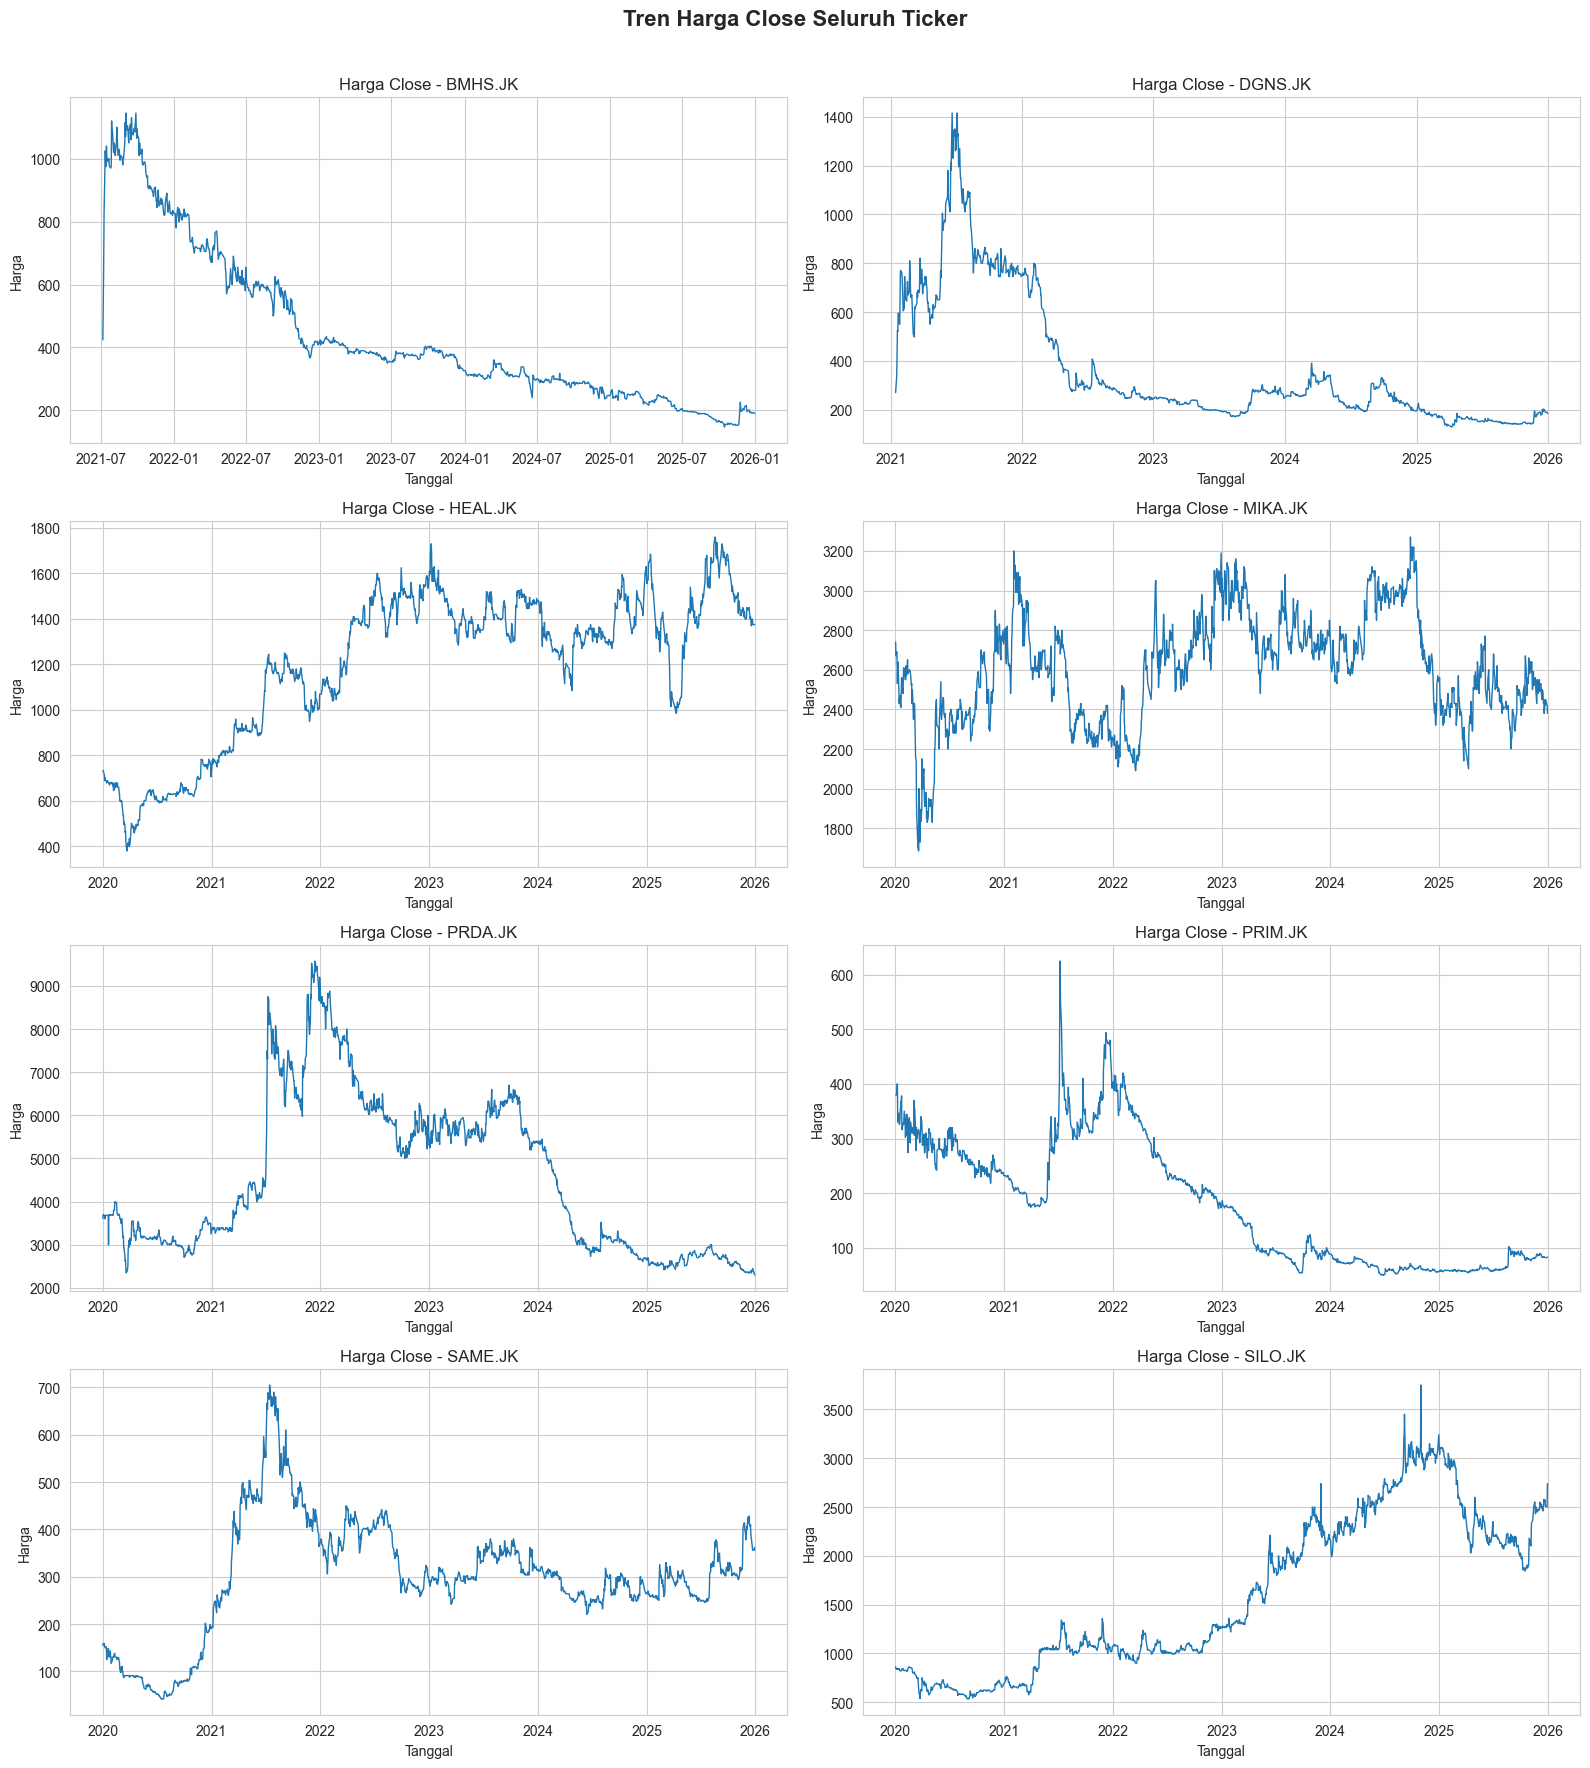

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, (ticker, df) in zip(axes, raw_data.items()):
    ax.plot(df.index, df['Close'], linewidth=1)
    ax.set_title(f"Harga Close - {ticker}")
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Harga")

plt.suptitle("Tren Harga Close Seluruh Ticker", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_price_trend.png", dpi=300)
plt.show()


### 5.4 Distribusi Return Harian

Histogram + KDE dari return harian tiap saham untuk melihat volatilitas dan bentuk sebaran (normal/skewed/fat-tail).


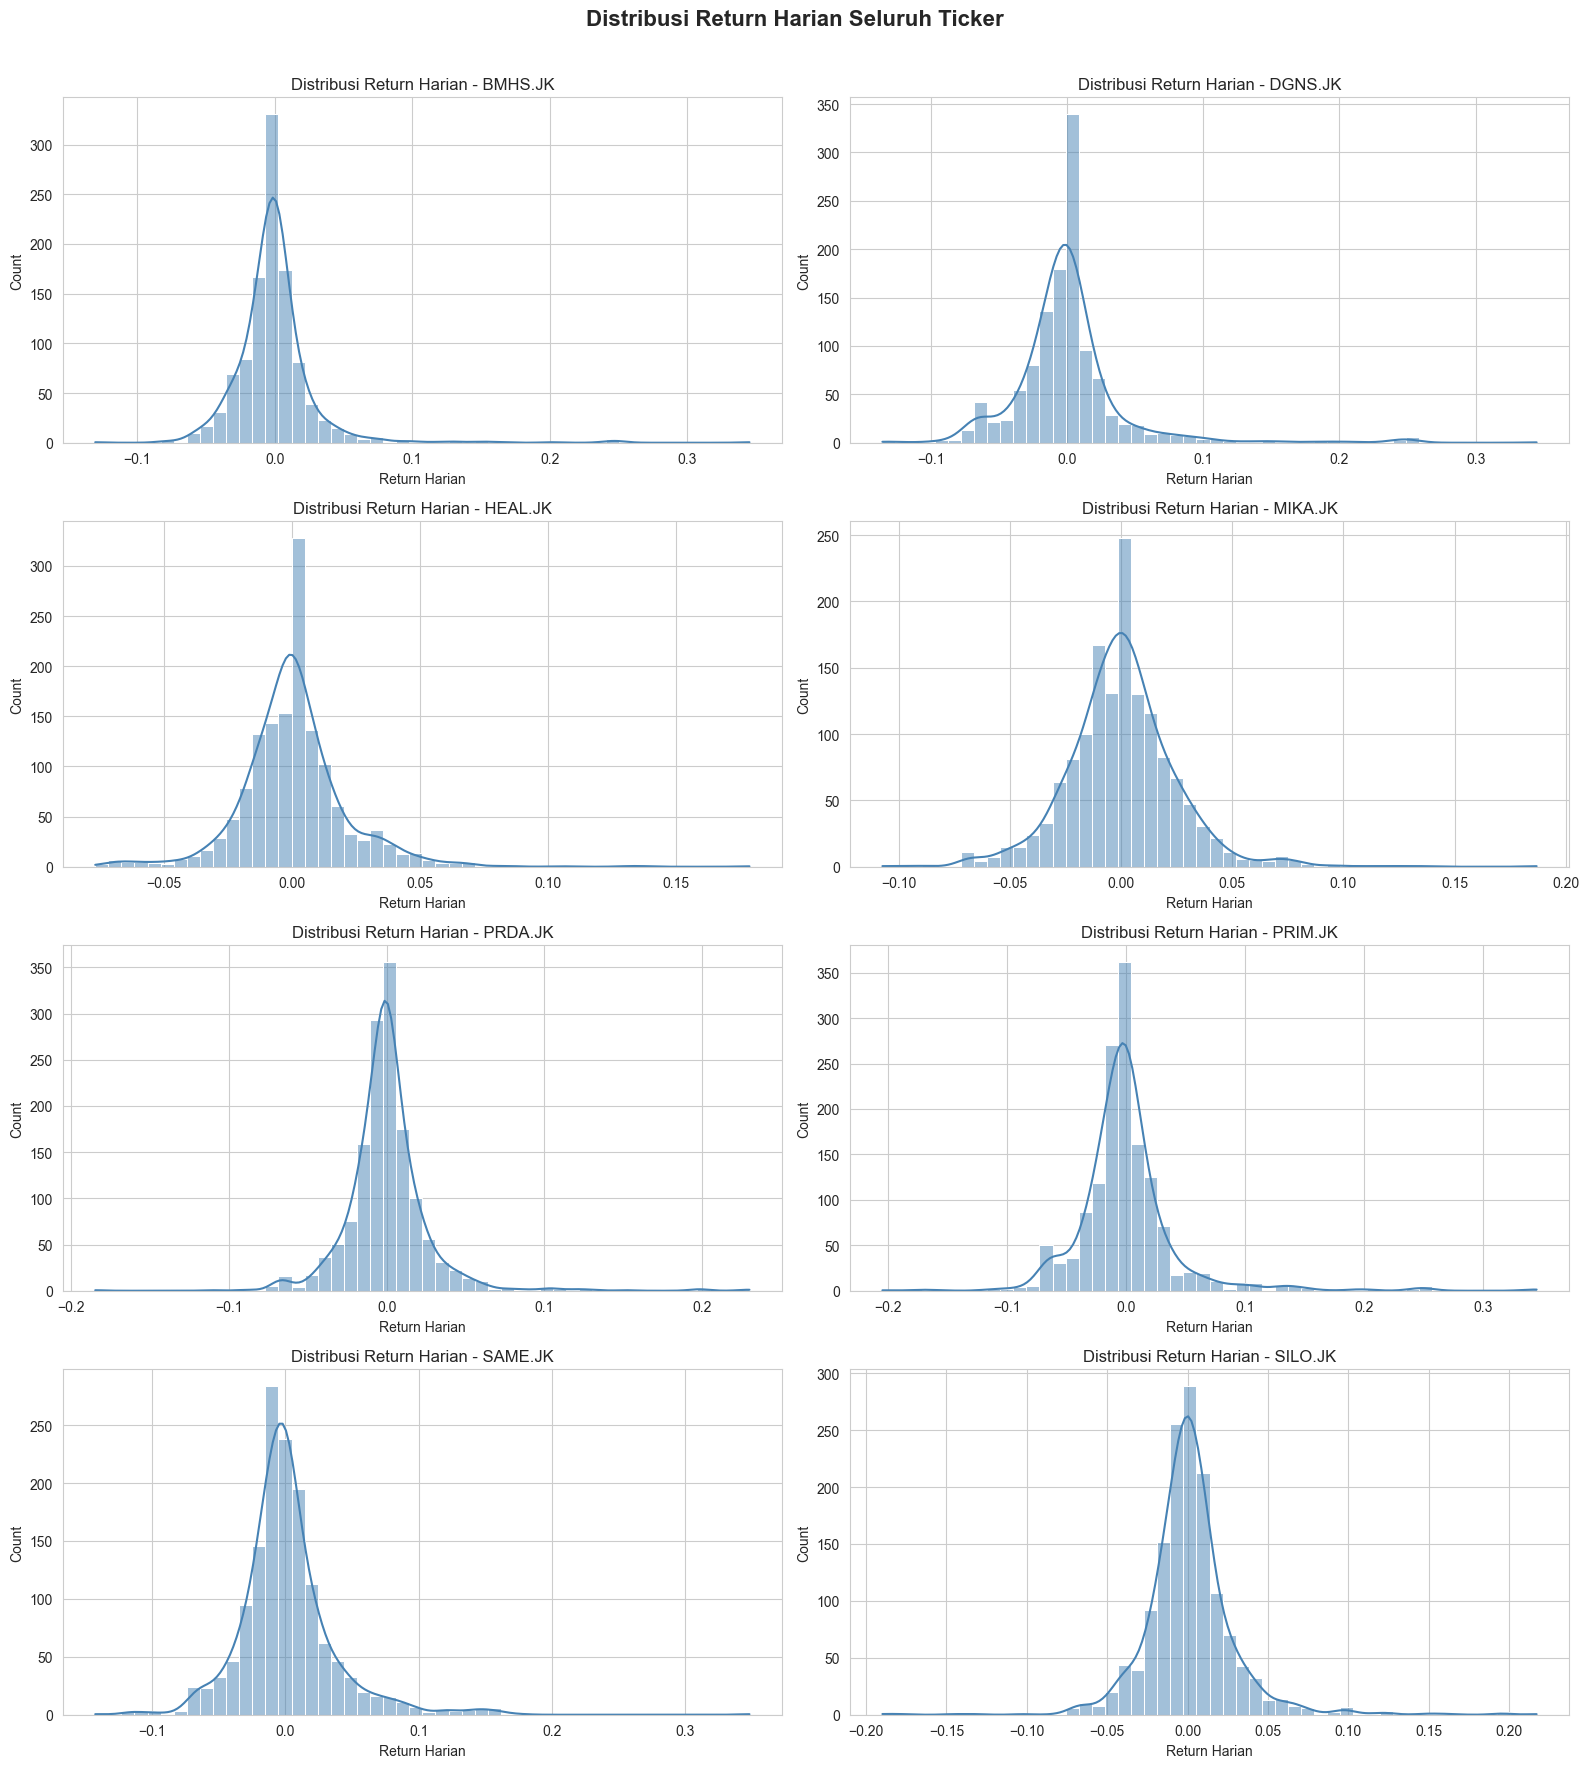

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, (ticker, df) in zip(axes, raw_data.items()):
    daily_return = df['Close'].pct_change().dropna()
    sns.histplot(daily_return, bins=50, kde=True, ax=ax, color='steelblue')
    ax.set_title(f"Distribusi Return Harian - {ticker}")
    ax.set_xlabel("Return Harian")

plt.suptitle("Distribusi Return Harian Seluruh Ticker", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_return_distribution.png", dpi=300)
plt.show()


### 5.5 Korelasi Harga Antar Saham

Heatmap korelasi harga Close antar ticker. Berguna untuk melihat apakah saham-saham ini bergerak searah
(misalnya karena satu sektor yang sama) yang berimplikasi pada diversifikasi jika dipakai bersamaan dalam portofolio.


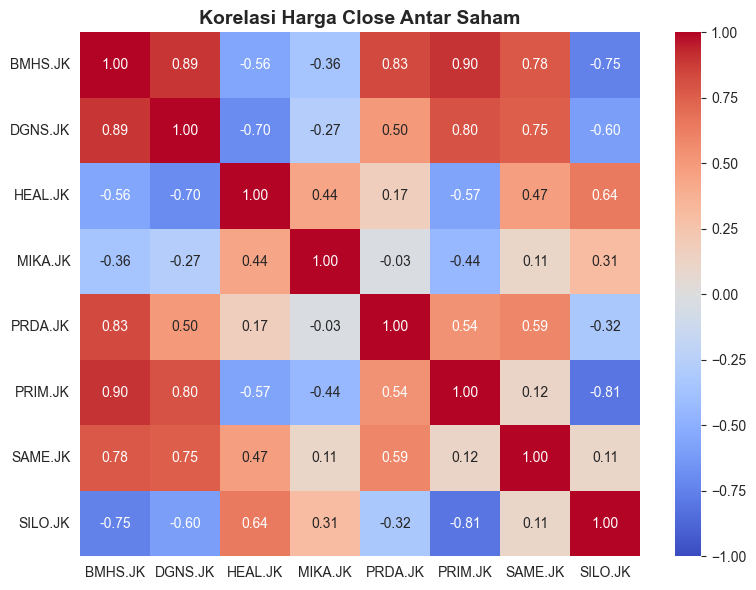

In [9]:
close_prices = pd.DataFrame({
    ticker: df['Close'] for ticker, df in raw_data.items()
})

corr_matrix = close_prices.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Harga Close Antar Saham", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=300)
plt.show()


## 6. Fungsi Feature Engineering & Labeling

Dibuat dalam bentuk fungsi (`add_features` dan `add_label`) agar bisa dipanggil ulang secara konsisten,
baik saat EDA fitur maupun saat proses modeling per ticker, tanpa duplikasi kode.

Fitur yang dihitung:
- `rsi`: Relative Strength Index (14 hari)
- `tema_20_rel`: posisi harga relatif terhadap TEMA 20 hari
- `bb_width`: lebar Bollinger Band (20, 2 std) relatif terhadap middle band
- `volume_rel`: volume hari ini relatif terhadap rata-rata volume 20 hari
- `momentum_5`: return 5 hari terakhir

Label dibuat dari return `lookup_periode` hari ke depan dibandingkan `threshold`:
- `1` (Buy) jika return masa depan > threshold
- `-1` (Sell) jika return masa depan < -threshold
- `0` (Hold) selain itu


In [10]:
def add_features(df):
    df = df.copy()

    df['rsi'] = ta.rsi(df['Close'], length=14)

    df['tema_20_rel'] = (
        df['Close'] / ta.tema(df['Close'], length=20)
    ) - 1

    bb = ta.bbands(df['Close'], length=20, std=2)
    df['bb_upper'] = bb['BBU_20_2.0']
    df['bb_middle'] = bb['BBM_20_2.0']
    df['bb_lower'] = bb['BBL_20_2.0']

    df['bb_width'] = (
        (df['bb_upper'] - df['bb_lower']) / df['bb_middle']
    )

    df['volume_rel'] = (
        df['Volume'] / df['Volume'].rolling(20).mean()
    )

    df['momentum_5'] = (
        df['Close'] / df['Close'].shift(5)
    ) - 1

    return df


def add_label(df, lookup_periode, threshold):
    df = df.copy()

    df["Future_Return"] = (
        df["Close"].shift(-lookup_periode) / df["Close"]
    ) - 1

    df["Label"] = 0
    df.loc[df["Future_Return"] > threshold, "Label"] = 1
    df.loc[df["Future_Return"] < -threshold, "Label"] = -1

    df = df.drop(columns=['Adj Close', 'Future_Return'], errors='ignore')
    df = df.dropna()

    return df


## 7. Terapkan Feature Engineering & Labeling ke Semua Ticker

Hasilnya disimpan di `processed_data` (dictionary per ticker) agar dipakai bersama oleh EDA fitur/label
maupun tahap modeling, tanpa menghitung ulang.


In [11]:
processed_data = {}

for ticker, df in raw_data.items():
    df_feat = add_features(df)
    df_feat = add_label(df_feat, lookup_periode, threshold)
    processed_data[ticker] = df_feat

print("Contoh data setelah feature engineering & labeling:")
processed_data[tickers_list[0]].tail()


Contoh data setelah feature engineering & labeling:


,Close,High,Low,Open,Volume,rsi,tema_20_rel,bb_upper,bb_middle,bb_lower,bb_width,volume_rel,momentum_5,Label
Date,,,,,,,,,,,,,,
2025-12-22,192.0,197.0,183.0,194.0,7018900,50.128087,-0.045380,215.285066,201.90,188.514934,0.132591,0.282392,-0.040000,0
2025-12-23,193.0,195.0,189.0,192.0,5599600,50.950765,-0.031576,214.762862,201.15,187.537138,0.135350,0.324431,-0.044554,0
2025-12-24,192.0,195.0,188.0,193.0,5125100,50.061437,-0.027798,214.984034,200.90,186.815966,0.140209,0.336840,-0.040000,0
2025-12-29,192.0,195.0,189.0,192.0,3299800,50.061437,-0.020335,215.172741,200.65,186.127259,0.144757,0.259069,-0.005181,0
2025-12-30,190.0,192.0,189.0,192.0,4969400,48.113489,-0.021717,215.466767,200.25,185.033233,0.151978,0.400319,-0.020619,0


## 8. EDA Fitur & Label

Setelah fitur dan label terbentuk, kita cek lagi sebarannya sebelum masuk ke modeling:
- Apakah label seimbang antar kelas (Buy/Hold/Sell)?
- Bagaimana bentuk distribusi tiap fitur di seluruh ticker?


### 8.1 Distribusi Label per Ticker

Melihat proporsi Sell/Hold/Buy di tiap saham. Distribusi yang timpang (misalnya Hold mendominasi)
adalah hal wajar untuk labeling berbasis threshold return, tapi penting diketahui karena
memengaruhi interpretasi hasil model nantinya (makanya `class_weight="balanced"` dipakai saat training).


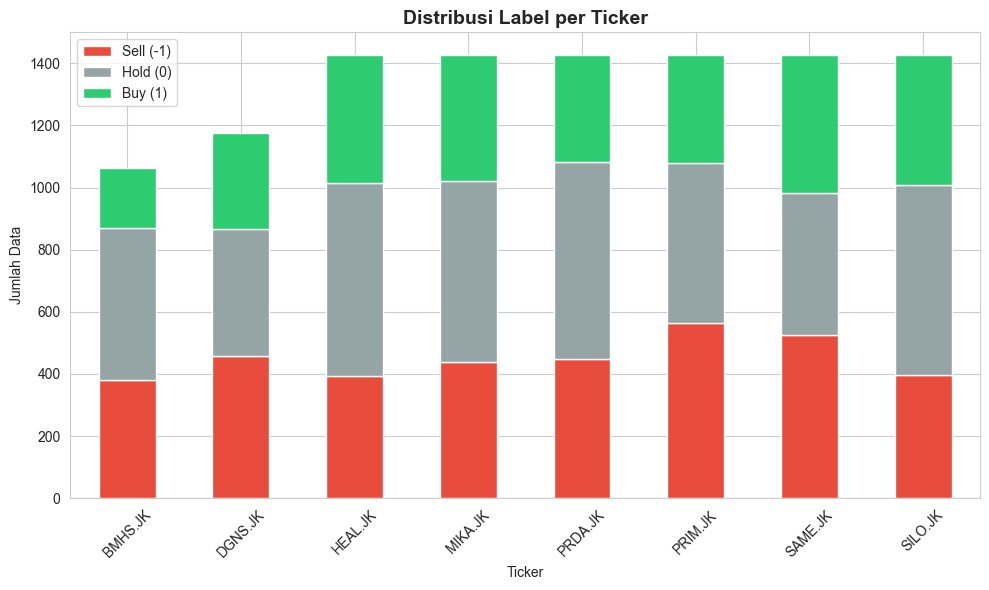

,Sell (-1),Hold (0),Buy (1)
Ticker,,,
BMHS.JK,381,489,193
DGNS.JK,458,409,310
HEAL.JK,393,621,414
MIKA.JK,439,581,408
PRDA.JK,448,634,346
PRIM.JK,565,515,348
SAME.JK,527,454,447
SILO.JK,396,611,421


In [12]:
label_counts = []

for ticker, df in processed_data.items():
    counts = df['Label'].value_counts().reindex([-1, 0, 1], fill_value=0)
    label_counts.append({
        "Ticker": ticker,
        "Sell (-1)": counts[-1],
        "Hold (0)": counts[0],
        "Buy (1)": counts[1]
    })

label_counts_df = pd.DataFrame(label_counts).set_index("Ticker")

label_counts_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#e74c3c', '#95a5a6', '#2ecc71']
)
plt.title("Distribusi Label per Ticker", fontsize=14, fontweight='bold')
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_label_distribution.png", dpi=300)
plt.show()

label_counts_df


### 8.2 Distribusi Tiap Fitur (Seluruh Ticker)

KDE plot untuk membandingkan bentuk sebaran tiap fitur antar saham. Berguna untuk mendeteksi
outlier ekstrem atau fitur yang skalanya sangat berbeda antar ticker.


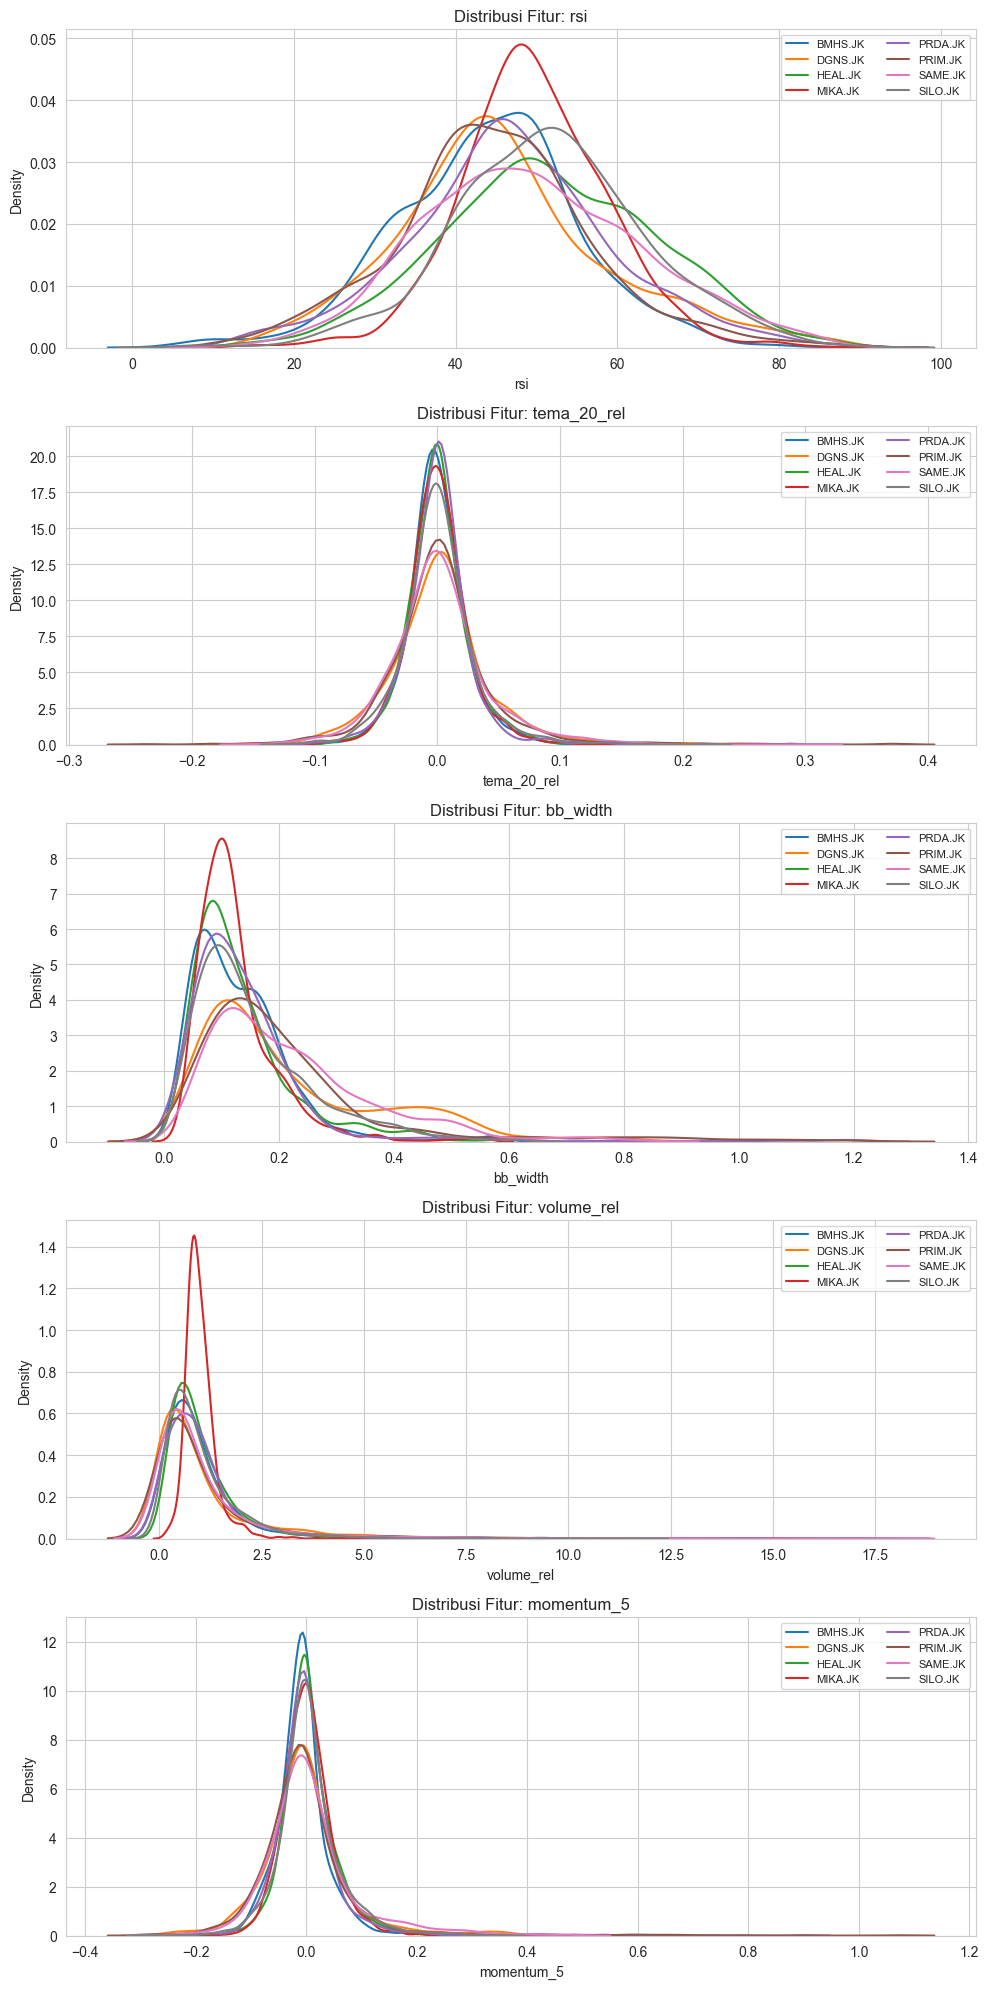

In [13]:
fig, axes = plt.subplots(len(features), 1, figsize=(10, 4 * len(features)))

for ax, feat in zip(axes, features):
    for ticker, df in processed_data.items():
        sns.kdeplot(df[feat], ax=ax, label=ticker)
    ax.set_title(f"Distribusi Fitur: {feat}")
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("eda_feature_distribution.png", dpi=300)
plt.show()


## 9. Modeling & Backtesting per Ticker

Untuk tiap ticker:
1. Split data menjadi Train (60%), Test (20%), Forward/Backtest (20%) secara berurutan (time-based split, bukan random).
2. Latih `RandomForestClassifier` dengan parameter hasil tuning (`rf_params_map`).
3. Evaluasi di data Test dan data Forward menggunakan accuracy, classification report, dan confusion matrix.
4. Jalankan backtest strategi trading berbasis sinyal model pada periode Forward menggunakan library `backtesting`.
5. Simpan hasil ringkasan performa ke `results`.


In [14]:
for ticker in tickers_list:

    if ticker not in processed_data:
        continue

    print(f"\n========================")
    print(f"PROCESSING {ticker}")
    print(f"========================")

    df = processed_data[ticker]

    X = df[features]
    Y = df['Label']

    total_len = len(df)
    train_idx = int(total_len * 0.60)
    test_idx = int(total_len * 0.80)

    X_train = X.iloc[:train_idx]
    Y_train = Y.iloc[:train_idx]

    X_test = X.iloc[train_idx:test_idx]
    Y_test = Y.iloc[train_idx:test_idx]

    X_forward = X.iloc[test_idx:]
    Y_forward = Y.iloc[test_idx:]

    df_forward = df.iloc[test_idx:].copy()

    print(f"Train   : {len(X_train)}")
    print(f"Test    : {len(X_test)}")
    print(f"Forward : {len(X_forward)}")

    # =====================
    # MODEL
    # =====================
    params = rf_params_map[ticker]

    rf_model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_features='sqrt'
    )

    rf_model.fit(X_train, Y_train)

    # =====================
    # PREDICTION
    # =====================
    Y_train_pred = rf_model.predict(X_train)
    Y_test_pred = rf_model.predict(X_test)
    Y_fwd_pred = rf_model.predict(X_forward)

    # =====================
    # CONFUSION MATRIX
    # =====================
    cm_test = confusion_matrix(Y_test, Y_test_pred, labels=[-1, 0, 1])
    cm_backtest = confusion_matrix(Y_forward, Y_fwd_pred, labels=[-1, 0, 1])

    testing_cms.append((ticker, cm_test))
    backtesting_cms.append((ticker, cm_backtest))

    # =====================
    # EVALUATION
    # =====================
    print(f"Test Accuracy     : {accuracy_score(Y_test, Y_test_pred):.4f}")
    print(f"Backtest Accuracy : {accuracy_score(Y_forward, Y_fwd_pred):.4f}")

    print("\nClassification Report (Test):")
    print(classification_report(Y_test, Y_test_pred))

    print("\nClassification Report (Backtest):")
    print(classification_report(Y_forward, Y_fwd_pred))

    # =====================
    # STRATEGY
    # =====================
    class RFStrategy(Strategy):

        def init(self):
            self.model = rf_model
            self.features = features

        def next(self):
            X_today = self.data.df.iloc[[-1]][self.features]
            signal = self.model.predict(X_today)[0]

            if signal == 1:
                if not self.position.is_long:
                    self.buy()
            elif signal == -1:
                if self.position.is_long:
                    self.position.close()

    # =====================
    # BACKTEST
    # =====================
    bt = Backtest(
        df_forward,
        RFStrategy,
        cash=100_000_000,
        commission=0.002,
        exclusive_orders=True,
        margin=1.0
    )

    stats = bt.run()

    print("\n=== BACKTEST RESULT ===")
    print(stats)

    # =====================
    # SAVE RESULT
    # =====================
    results.append({
        "Ticker": ticker,
        "Buy Hold Return (%)": stats["Buy & Hold Return [%]"],
        "Return (%)": stats["Return [%]"],
        "Sharpe Ratio": stats["Sharpe Ratio"],
        "Win Rate (%)": stats["Win Rate [%]"],
        "Max Drawdown (%)": stats["Max. Drawdown [%]"],
        "Jumlah Trade": stats["# Trades"],
    })



PROCESSING BMHS.JK
Train   : 637
Test    : 213
Forward : 213
Test Accuracy     : 0.4460
Backtest Accuracy : 0.4648

Classification Report (Test):
              precision    recall  f1-score   support

          -1       0.43      0.46      0.44        79
           0       0.44      0.57      0.49        90
           1       0.62      0.18      0.28        44

    accuracy                           0.45       213
   macro avg       0.50      0.40      0.41       213
weighted avg       0.47      0.45      0.43       213


Classification Report (Backtest):
              precision    recall  f1-score   support

          -1       0.30      0.19      0.23        74
           0       0.54      0.81      0.65       103
           1       0.14      0.06      0.08        36

    accuracy                           0.46       213
   macro avg       0.33      0.35      0.32       213
weighted avg       0.39      0.46      0.41       213



Backtest.run:   0%|          | 0/212 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2025-02-07 00:00:00
End                       2025-12-30 00:00:00
Duration                    326 days 00:00:00
Exposure Time [%]                    24.88263
Equity Final [$]                 86585053.164
Equity Peak [$]                   100000000.0
Commissions [$]                   2638578.836
Return [%]                          -13.41495
Buy & Hold Return [%]               -20.16807
Return (Ann.) [%]                    -15.6687
Volatility (Ann.) [%]                13.48827
CAGR [%]                            -10.53709
Sharpe Ratio                         -1.16165
Sortino Ratio                        -1.27737
Calmar Ratio                         -0.79178
Alpha [%]                            -10.8041
Beta                                  0.12945
Max. Drawdown [%]                   -19.78924
Avg. Drawdown [%]                   -19.78924
Max. Drawdown Duration      285 days 00:00:00
Avg. Drawdown Duration      285 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2025-01-02 00:00:00
End                       2025-12-30 00:00:00
Duration                    362 days 00:00:00
Exposure Time [%]                    31.35593
Equity Final [$]                 97831654.168
Equity Peak [$]                 111495734.638
Commissions [$]                   5267841.832
Return [%]                           -2.16835
Buy & Hold Return [%]                -6.59898
Return (Ann.) [%]                    -2.31364
Volatility (Ann.) [%]                38.05935
CAGR [%]                             -1.51448
Sharpe Ratio                         -0.06079
Sortino Ratio                        -0.12005
Calmar Ratio                         -0.07969
Alpha [%]                             0.10879
Beta                                  0.34507
Max. Drawdown [%]                   -29.03308
Avg. Drawdown [%]                   -21.23629
Max. Drawdown Duration      249 days 00:00:00
Avg. Drawdown Duration      178 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    66.78322
Equity Final [$]                  72187626.83
Equity Peak [$]                  110715528.39
Commissions [$]                   11302808.17
Return [%]                          -27.81237
Buy & Hold Return [%]               -11.29032
Return (Ann.) [%]                   -24.96068
Volatility (Ann.) [%]                19.97154
CAGR [%]                            -17.06209
Sharpe Ratio                         -1.24981
Sortino Ratio                        -1.23098
Calmar Ratio                         -0.67634
Alpha [%]                           -22.29464
Beta                                  0.48871
Max. Drawdown [%]                   -36.90563
Avg. Drawdown [%]                   -10.94522
Max. Drawdown Duration      397 days 00:00:00
Avg. Drawdown Duration      107 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    65.73427
Equity Final [$]                   99091771.5
Equity Peak [$]                   102006221.5
Commissions [$]                     4865343.2
Return [%]                           -0.90823
Buy & Hold Return [%]               -22.97735
Return (Ann.) [%]                    -0.80069
Volatility (Ann.) [%]                30.55444
CAGR [%]                             -0.52236
Sharpe Ratio                         -0.02621
Sortino Ratio                        -0.03943
Calmar Ratio                         -0.03718
Alpha [%]                            13.40254
Beta                                  0.62282
Max. Drawdown [%]                   -21.53822
Avg. Drawdown [%]                    -6.29744
Max. Drawdown Duration      336 days 00:00:00
Avg. Drawdown Duration       86 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    58.04196
Equity Final [$]                   98960873.3
Equity Peak [$]                  105612877.08
Commissions [$]                     2756076.7
Return [%]                           -1.03913
Buy & Hold Return [%]               -24.59016
Return (Ann.) [%]                    -0.91616
Volatility (Ann.) [%]                14.85624
CAGR [%]                             -0.59782
Sharpe Ratio                         -0.06167
Sortino Ratio                        -0.08683
Calmar Ratio                         -0.05707
Alpha [%]                             9.47692
Beta                                  0.42765
Max. Drawdown [%]                   -16.05312
Avg. Drawdown [%]                    -5.47473
Max. Drawdown Duration      217 days 00:00:00
Avg. Drawdown Duration       55 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    44.75524
Equity Final [$]                 92180628.672
Equity Peak [$]                  116724085.86
Commissions [$]                   6492465.328
Return [%]                           -7.81937
Buy & Hold Return [%]                33.87097
Return (Ann.) [%]                    -6.92279
Volatility (Ann.) [%]                43.37794
CAGR [%]                             -4.56624
Sharpe Ratio                         -0.15959
Sortino Ratio                        -0.34261
Calmar Ratio                         -0.19877
Alpha [%]                           -30.56771
Beta                                  0.67162
Max. Drawdown [%]                   -34.82897
Avg. Drawdown [%]                   -19.26043
Max. Drawdown Duration      302 days 00:00:00
Avg. Drawdown Duration      141 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                    49.65035
Equity Final [$]                127511367.336
Equity Peak [$]                 151900645.096
Commissions [$]                   4582028.664
Return [%]                           27.51137
Buy & Hold Return [%]                27.46479
Return (Ann.) [%]                    23.87998
Volatility (Ann.) [%]                52.44471
CAGR [%]                             14.97103
Sharpe Ratio                          0.45534
Sortino Ratio                         1.08443
Calmar Ratio                          0.96426
Alpha [%]                            10.71078
Beta                                  0.61171
Max. Drawdown [%]                   -24.76521
Avg. Drawdown [%]                    -8.88361
Max. Drawdown Duration      133 days 00:00:00
Avg. Drawdown Duration       34 days 00:00:00
# Trades 

Backtest.run:   0%|          | 0/285 [00:00<?, ?bar/s]


=== BACKTEST RESULT ===
Start                     2024-10-17 00:00:00
End                       2025-12-30 00:00:00
Duration                    439 days 00:00:00
Exposure Time [%]                     45.1049
Equity Final [$]                  81819072.88
Equity Peak [$]                   100000000.0
Commissions [$]                    5996127.12
Return [%]                          -18.18093
Buy & Hold Return [%]               -12.17949
Return (Ann.) [%]                    -16.2057
Volatility (Ann.) [%]                27.62616
CAGR [%]                            -10.87989
Sharpe Ratio                         -0.58661
Sortino Ratio                        -0.68219
Calmar Ratio                         -0.41076
Alpha [%]                           -11.21634
Beta                                  0.57183
Max. Drawdown [%]                   -39.45329
Avg. Drawdown [%]                   -39.45329
Max. Drawdown Duration      425 days 00:00:00
Avg. Drawdown Duration      425 days 00:00:00
# Trades 

## 10. Visualisasi Confusion Matrix

Fungsi untuk menampilkan 4 confusion matrix sekaligus dalam satu gambar (grid 2x2), dipakai untuk
membandingkan performa Testing dan Backtesting antar kelompok ticker.


In [15]:
def plot_group_confusion_matrix(cm_list, title, filename):

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for ax, (ticker, cm) in zip(axes, cm_list):
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            ax=ax
        )
        ax.set_title(ticker, fontsize=12)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.suptitle(title, fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(filename, dpi=300)
    plt.show()


### 10.1 Confusion Matrix - Testing (Ticker 1-4 dan 5-8)


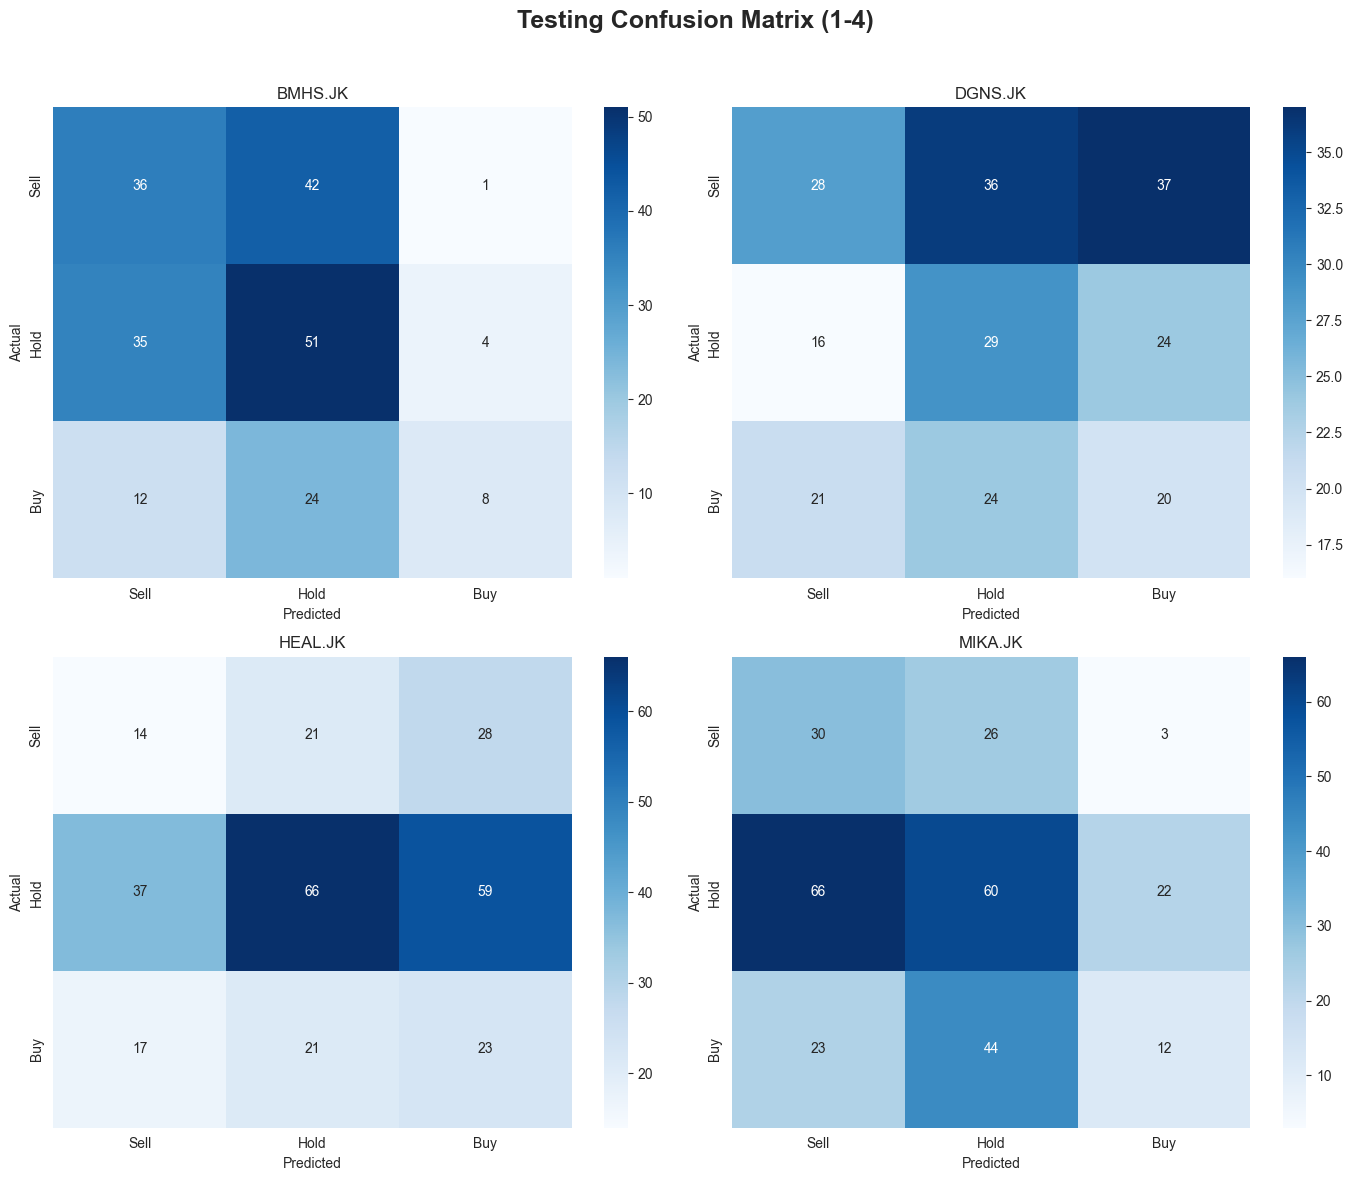

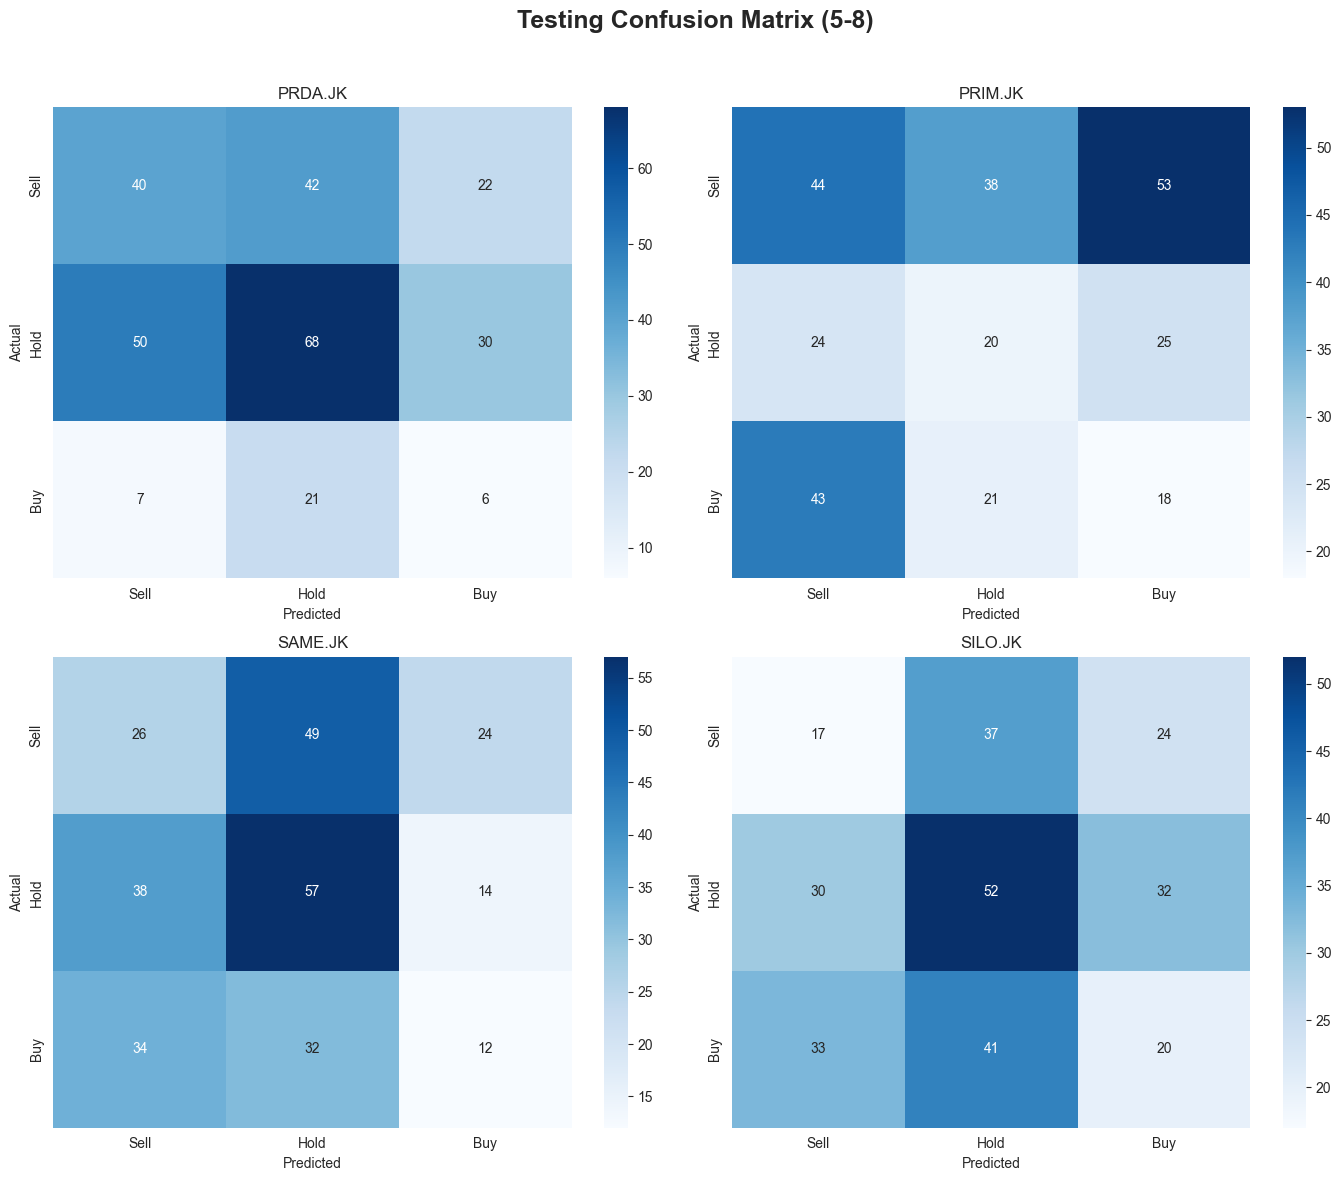

In [16]:
plot_group_confusion_matrix(
    testing_cms[:4],
    "Testing Confusion Matrix (1-4)",
    "testing_confusion_matrix_1.png"
)

plot_group_confusion_matrix(
    testing_cms[4:8],
    "Testing Confusion Matrix (5-8)",
    "testing_confusion_matrix_2.png"
)


### 10.2 Confusion Matrix - Backtesting (Ticker 1-4 dan 5-8)


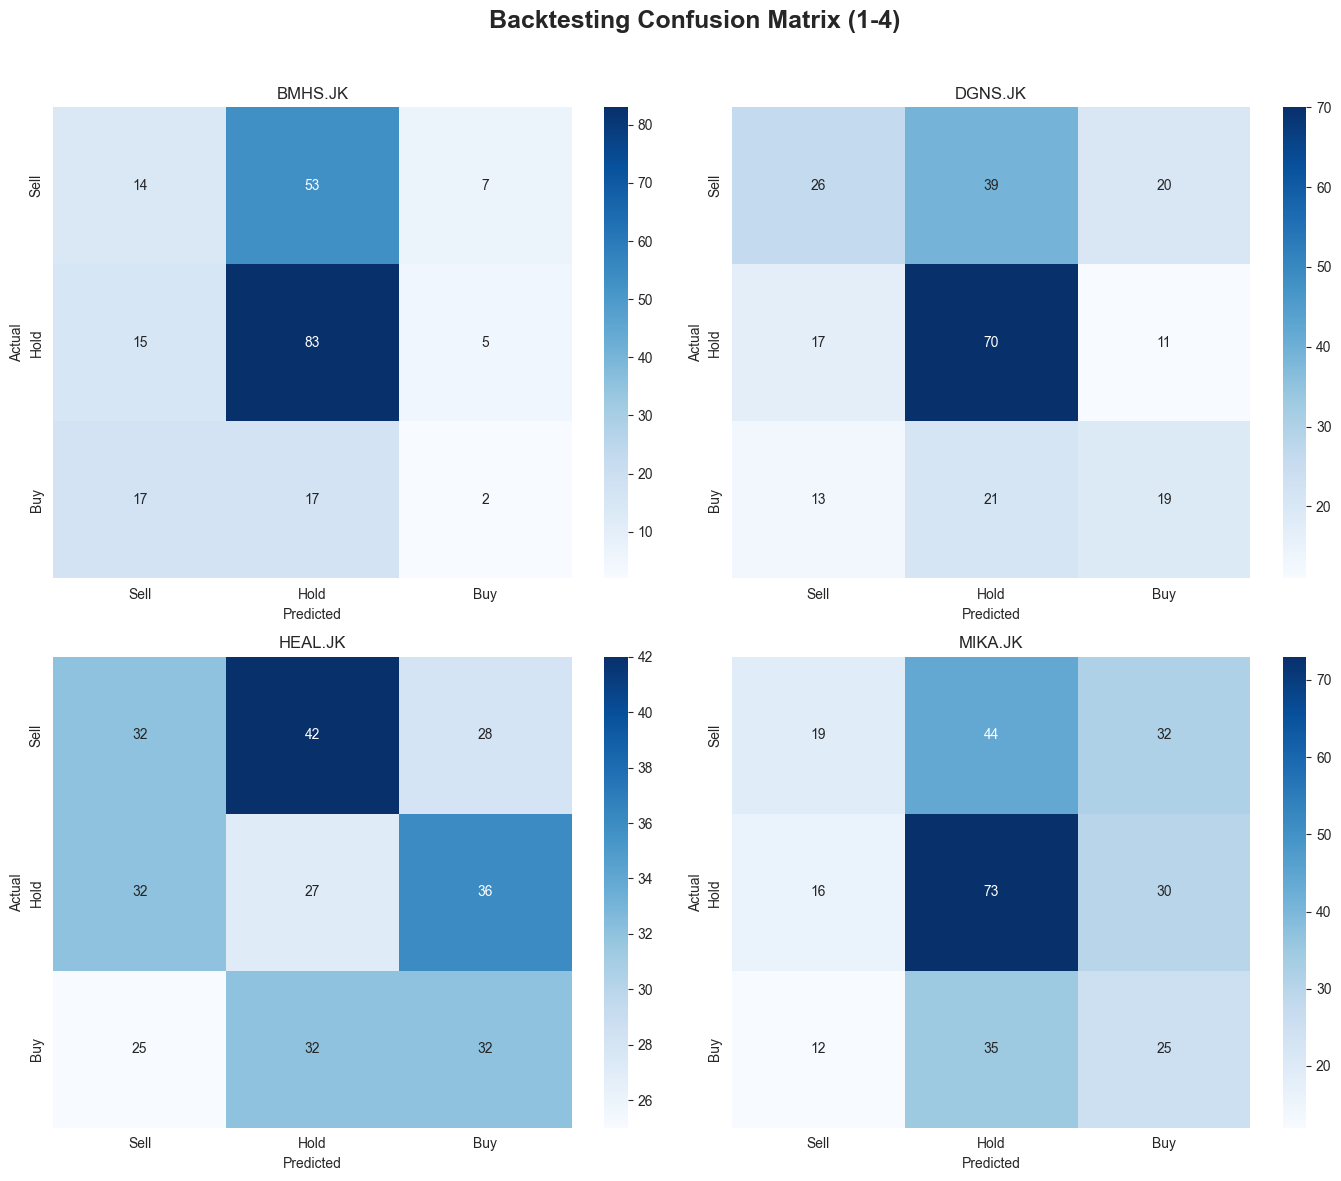

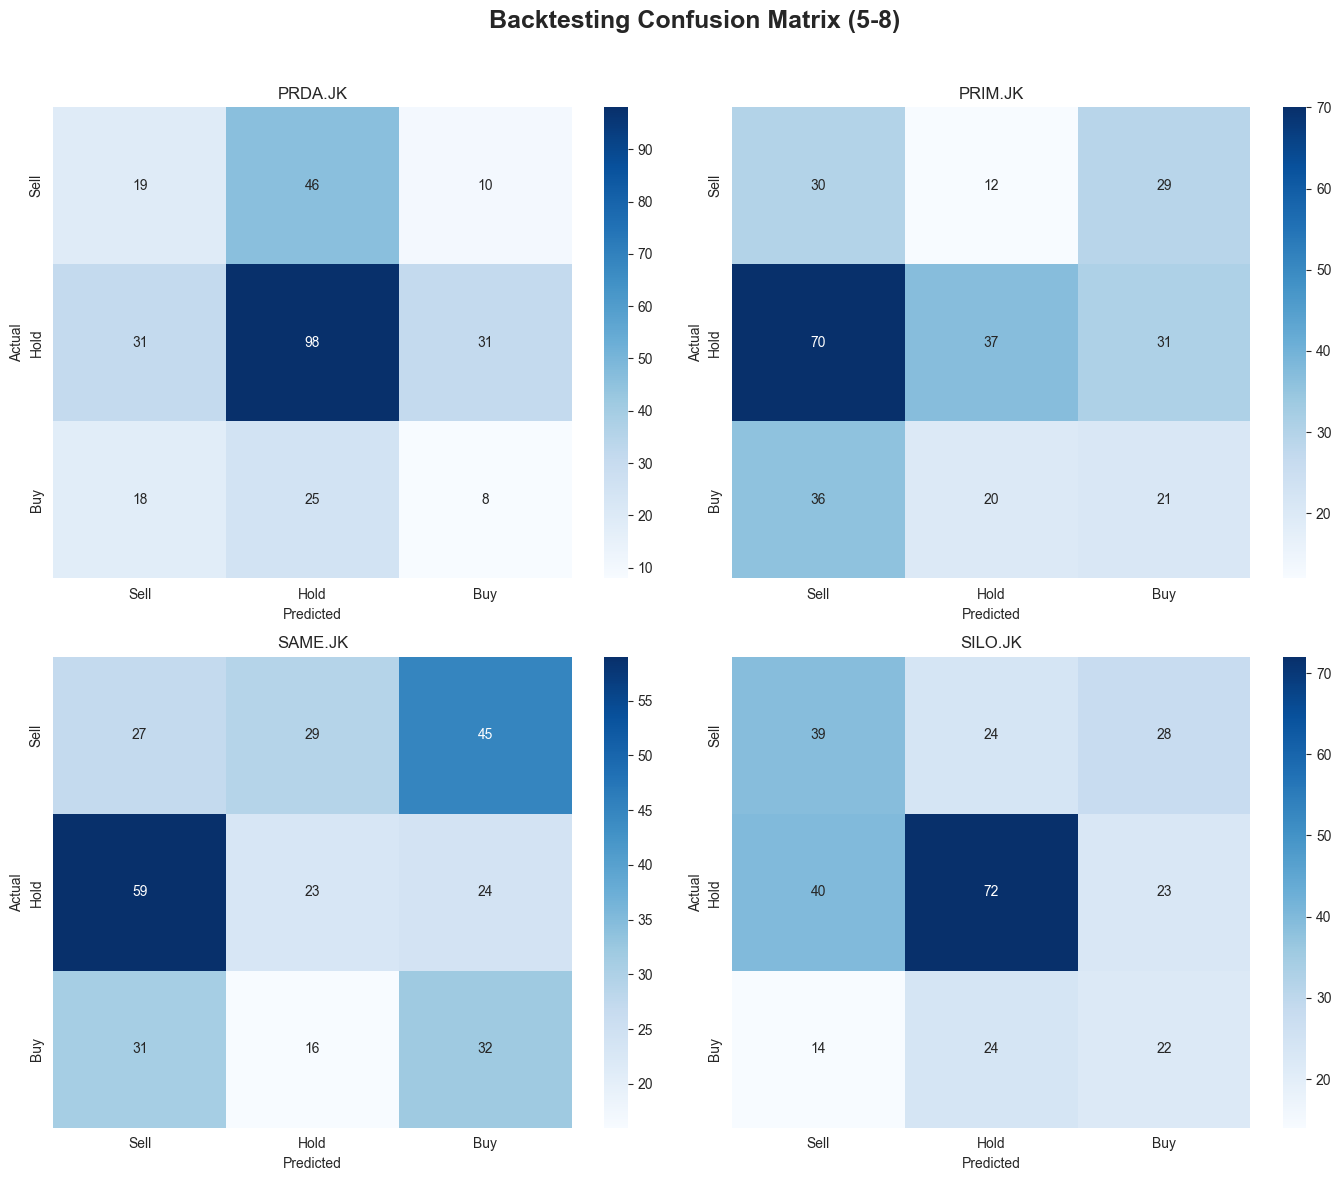

In [17]:
plot_group_confusion_matrix(
    backtesting_cms[:4],
    "Backtesting Confusion Matrix (1-4)",
    "backtesting_confusion_matrix_1.png"
)

plot_group_confusion_matrix(
    backtesting_cms[4:8],
    "Backtesting Confusion Matrix (5-8)",
    "backtesting_confusion_matrix_2.png"
)


## 11. Ringkasan Hasil Backtest Seluruh Ticker

Menampilkan tabel ringkasan performa (Return, Buy & Hold Return, Sharpe Ratio, Win Rate, Max Drawdown,
Jumlah Trade) untuk seluruh ticker dalam satu tabel agar mudah dibandingkan.


In [18]:
results_df = pd.DataFrame(results)

print("==============================")
print("=== HASIL BACKTEST SEMUA TICKER ===")
print("==============================")

results_df


=== HASIL BACKTEST SEMUA TICKER ===


,Ticker,Buy Hold Return (%),Return (%),Sharpe Ratio,Win Rate (%),Max Drawdown (%),Jumlah Trade
0,BMHS.JK,-20.168067,-13.414947,-1.161653,42.857143,-19.789242,7
1,DGNS.JK,-6.598985,-2.168346,-0.060790,35.714286,-29.033084,14
2,HEAL.JK,-11.290323,-27.812373,-1.249813,42.424242,-36.905626,33
3,MIKA.JK,-22.977346,-0.908228,-0.026205,61.538462,-21.538216,13
4,PRDA.JK,-24.590164,-1.039127,-0.061668,57.142857,-16.053118,7
5,PRIM.JK,33.870968,-7.819371,-0.159592,35.294118,-34.828973,17
6,SAME.JK,27.464789,27.511367,0.455336,45.454545,-24.765209,11
7,SILO.JK,-12.179487,-18.180927,-0.586607,35.000000,-39.453285,20
